<a href="https://colab.research.google.com/github/Thomas-18/lab/blob/main/Linear%20regression%20and%20polynomial%20regression2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [43]:
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
data=pd.read_csv(url)

data=data[['mpg','displacement']]
data.dropna(inplace=True)

print(data.head())

    mpg  displacement
0  18.0         307.0
1  15.0         350.0
2  18.0         318.0
3  16.0         304.0
4  17.0         302.0


In [44]:
X=data[['displacement']]
y=data['mpg']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [45]:
linear_model=LinearRegression()
linear_model.fit(X_train,y_train)

y_pred=linear_model.predict(X_test)
print("Linear Regression")
print("MSE=",mean_squared_error(y_test,y_pred))

Linear Regression
MSE= 18.102543998358946


In [46]:
degrees=[2,3,4]
for degree in degrees:
    poly=PolynomialFeatures(degree=degree)
    X_train_poly=poly.fit_transform(X_train)
    X_test_poly=poly.fit_transform(X_test)
    model=LinearRegression()
    model.fit(X_train_poly,y_train)
    y_pred=model.predict(X_test_poly)
    print("\nDegree=",degree)
    print("MSE=",mean_squared_error(y_test,y_pred))
    print("R2=",r2_score(y_test,y_pred))


Degree= 2
MSE= 15.10735356108076
R2= 0.7190189176110284

Degree= 3
MSE= 14.943631793037289
R2= 0.722063972418907

Degree= 4
MSE= 14.961486893912738
R2= 0.7217318860908903


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


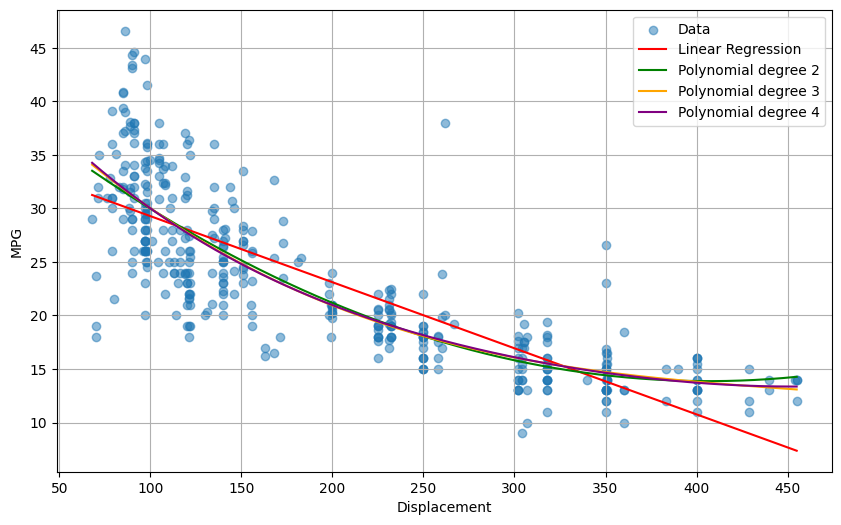

In [52]:
x_range=np.linspace(X.min(),X.max(),300).reshape(-1,1)
plt.figure(figsize=(10,6))
plt.scatter(X,y,alpha=0.5,label='Data')
plt.plot(x_range,linear_model.predict(x_range),label='Linear Regression',color='red')
colors=['green','orange','purple']
for degree,color in zip(degrees,colors):
    poly=PolynomialFeatures(degree=degree)
    X_poly=poly.fit_transform(X)
    x_range_poly=poly.fit_transform(x_range)
    model=LinearRegression()
    model.fit(X_poly,y)
    plt.plot(x_range,model.predict(x_range_poly),color=color,label=f'Polynomial degree {degree}')
plt.xlabel('Displacement')
plt.ylabel('MPG')
plt.legend()
plt.grid()
plt.show()